In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2 as cv
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab.patches import cv2_imshow
from sklearn.metrics import classification_report, confusion_matrix
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

Loading Train Data

In [ ]:
# Reading the train labels from csv file and displaying first five rows

df = pd.read_csv('/content/drive/MyDrive/Project Models/trainLabels.csv',dtype = str)
df.head()

,image,level
0,10_left,0
1,10_right,0
2,13_left,0
3,13_right,0
4,15_left,1


In [ ]:
# Training data Shape
df.shape

(10000, 2)

In [ ]:
#  Train Labels Distribution

df['level'].value_counts()

0    7257
2    1585
1     731
3     240
4     187
Name: level, dtype: int64

In [ ]:
# Loading Train Dataset

def append_ext(fn):
  return fn+".jpeg"       #-----> This function appends the .jpeg extension to the names of the images in the csv file as the real images comes with a .jpeg extension.
                                  # for ex csv file talks about the image name as 10_left, but the actual image has 10_left.jpeg. In order to relate them correctly we append .jpeg extension.
df["image"]=df["image"].apply(append_ext)

datagen = ImageDataGenerator()
train_generator = datagen.flow_from_dataframe(dataframe = df, directory = '/content/drive/MyDrive/Project Datasets/train_set',
                                              x_col = 'image', y_col = 'level', class_mode = 'categorical', target_size = (256,256),
                                              batch_size = 10000, color_mode='grayscale') #-- Converting the image to grayscale

Found 10000 validated image filenames belonging to 5 classes.


In [ ]:

x, y = train_generator.next() # --> x contains images, y contains labels wrt to each image. Size of this x and y variable after one iteration would be equal to the batchsize mentioned in the above program.


In [ ]:
x.shape

(10000, 256, 256, 1)

Image Preprocessing

In [ ]:
def preprocessing_img(img):
  target_type_min=0
  target_type_max=255
  target_type = np.uint8
  imin = img.min()
  imax = img.max()
  a = (target_type_max - target_type_min) / (imax - imin)
  b = target_type_max - a * imax
  img1 = (a * img + b).astype(target_type)                  # Converting dtype of image to 'uint8' for further preprocessing
  img2 = cv.normalize(img1, img1, 0, 255, cv.NORM_MINMAX)   # Normalizing the image
  imgGray = img2                                                    
  clahe = cv.createCLAHE(clipLimit=7.0, tileGridSize=(8,8)) # To increase the contrast of the images for better visibility
  contrast = clahe.apply(imgGray)
  contrast_list = contrast.tolist()
  contrast_list = np.array(contrast_list, dtype='uint8')
  #cv2_imshow(contrast_list)
  contrast_list=contrast_list.reshape(256,256,1)
  return contrast_list

In [ ]:
for i in range(len(x)):
  x[i] = preprocessing_img(x[i])      # Applying the defined preprocessing function to all the train images

Label: 0


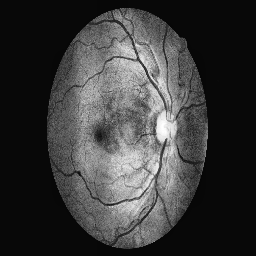


Label: 0


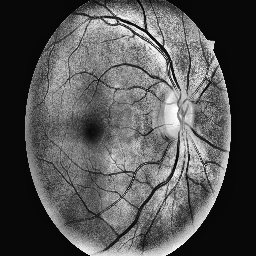


Label: 0


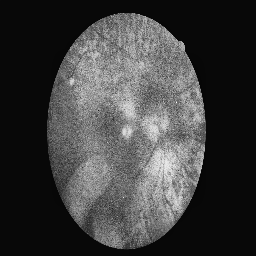


Label: 0


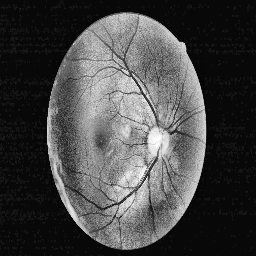


Label: 0


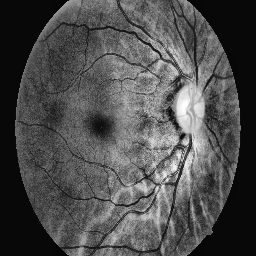

In [ ]:
y1 = y.argmax(axis=1)                     # Converting onehotencoded labels to its original format
                                                  
for i in range(5):                        # Displaying some sample train images
  print(f'Label: {y1[i]}')
  cv2_imshow(x[i])
  print()

In [ ]:
#Displaying first 10 onehotencoded labels
for i in range(10):
  print(y[i])

[1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0.]
[0. 0. 0. 0. 1.]


Loading Test Data

In [ ]:
# Reading the test labels from csv file and displaying first five rows

df1 = pd.read_csv('/content/drive/MyDrive/Project Models/testLabels.csv', dtype = str)
df1.head()

,image,level
0,40570_left,0
1,40570_right,1
2,40571_left,0
3,40571_right,0
4,40575_left,2


In [ ]:
# Testing data Shape

df1.shape

(3000, 2)

In [ ]:
#  Testing Labels Distribution

df1['level'].value_counts()

0    2252
2     418
1     219
3      56
4      55
Name: level, dtype: int64

In [ ]:
def append_ext(fn):
  return fn+".jpeg"
df1["image"]=df1["image"].apply(append_ext)

datagen1 = ImageDataGenerator()
test_generator = datagen1.flow_from_dataframe(dataframe = df1, directory = '/content/drive/MyDrive/Project Datasets/test_set',
                                              x_col = 'image', y_col = 'level', class_mode = 'categorical', target_size = (256,256),
                                              batch_size = 3000, color_mode='grayscale')

Found 3000 validated image filenames belonging to 5 classes.


In [ ]:
x_test , y_test = test_generator.next()

In [ ]:
x_test.shape

(3000, 256, 256, 1)

In [ ]:
for i in range(len(x_test)):
  x_test[i] = preprocessing_img(x_test[i])

Label: 0


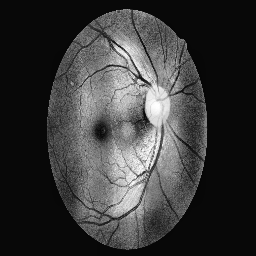


Label: 0


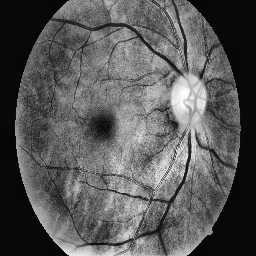


Label: 0


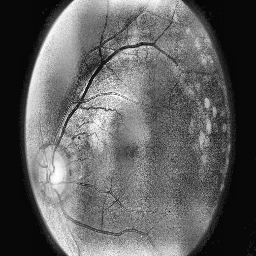

In [ ]:
y_test1 = y_test.argmax(axis=1)
for i in range(3):
  print(f'Label: {y_test1[i]}')
  cv2_imshow(x_test[i])
  print()

CNN

In [ ]:
# CNN Model
def dr_model(ishape = (256,256,1), ndim =5, lr = 1e-4):
  input_img  =  tf.keras.layers.Input(shape = ishape)
  conv1      =  tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
  conv2      =  tf.keras.layers.Conv2D(128, (3,3), activation='relu',padding='same')(conv1)
  drop1      =  tf.keras.layers.Dropout(0.5)(conv2)
  max1       =  tf.keras.layers.MaxPool2D((2,2))(drop1)
  conv3      =  tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(max1)
  conv4      =  tf.keras.layers.Conv2D(512, (3,3), activation='relu', padding='same')(conv3)
  drop2      =  tf.keras.layers.Dropout(0.5)(conv4)
  max2       =  tf.keras.layers.MaxPool2D((2,2))(drop2)
  flat       =  tf.keras.layers.Flatten()(max2)
  out        =  tf.keras.layers.Dense(ndim, activation='softmax')(flat)
  model      =  tf.keras.models.Model(inputs = input_img, outputs = out)
  model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=lr), loss = 'categorical_crossentropy', metrics = ['accuracy'])
  return model

In [ ]:
model = dr_model()
model.summary()

Model: "model_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_11 (InputLayer)        [(None, 256, 256, 1)]     0         
_________________________________________________________________
conv2d_43 (Conv2D)           (None, 256, 256, 64)      640       
_________________________________________________________________
conv2d_44 (Conv2D)           (None, 256, 256, 128)     73856     
_________________________________________________________________
dropout_19 (Dropout)         (None, 256, 256, 128)     0         
_________________________________________________________________
max_pooling2d_24 (MaxPooling (None, 128, 128, 128)     0         
_________________________________________________________________
conv2d_45 (Conv2D)           (None, 128, 128, 256)     295168    
_________________________________________________________________
conv2d_46 (Conv2D)           (None, 128, 128, 512)     1180

In [ ]:
# Call backs
model_name = "dr_model.h5"

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience = 20)

model_check_point = tf.keras.callbacks.ModelCheckpoint(model_name, monitor='val_loss', save_best_only=True, save_weights_only=True)

def scheduler(epoch, lr):
    if epoch%15==0:
      lr = lr/2
    return lr

lr_schedule = tf.keras.callbacks.LearningRateScheduler(scheduler,verbose = 0)

Defining Class Weights

In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced',np.unique(y1),y1)
class_weights_dict = dict(enumerate(class_weights))
class_weights_dict

{0: 0.27559597629874605,
 1: 2.735978112175103,
 2: 1.2618296529968454,
 3: 8.333333333333334,
 4: 10.695187165775401}

CNN Model Training

In [ ]:
# Model Training
history = model.fit(x,y, batch_size=32, epochs=15, callbacks=[model_check_point,early_stop,lr_schedule],validation_split=0.3,class_weight=class_weights_dict)

Epoch 1/15
219/219 [==============================] - 140s 630ms/step - loss: 75.8991 - accuracy: 0.2066 - val_loss: 1.5974 - val_accuracy: 0.1333
Epoch 2/15
219/219 [==============================] - 133s 608ms/step - loss: 1.5834 - accuracy: 0.1856 - val_loss: 1.6184 - val_accuracy: 0.1703
Epoch 3/15
219/219 [==============================] - 133s 608ms/step - loss: 1.4889 - accuracy: 0.2275 - val_loss: 1.5909 - val_accuracy: 0.1690
Epoch 4/15
219/219 [==============================] - 133s 608ms/step - loss: 1.4586 - accuracy: 0.2850 - val_loss: 1.5284 - val_accuracy: 0.1797
Epoch 5/15
219/219 [==============================] - 133s 608ms/step - loss: 1.3289 - accuracy: 0.2821 - val_loss: 1.4451 - val_accuracy: 0.2933
Epoch 6/15
219/219 [==============================] - 133s 607ms/step - loss: 1.1925 - accuracy: 0.3578 - val_loss: 1.3792 - val_accuracy: 0.3680
Epoch 7/15
219/219 [==============================] - 133s 608ms/step - loss: 1.1040 - accuracy: 0.4150 - val_loss: 1.4000 

In [ ]:
# Evaluating model for test data
model.load_weights(model_name)
model.evaluate(x_test,y_test)

94/94 [==============================] - 11s 113ms/step - loss: 1.0777 - accuracy: 0.6090


[1.0776820182800293, 0.609000027179718]

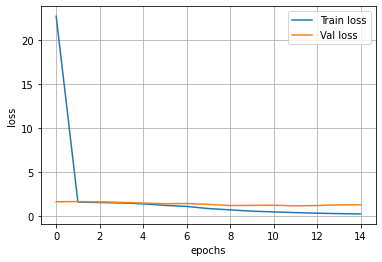

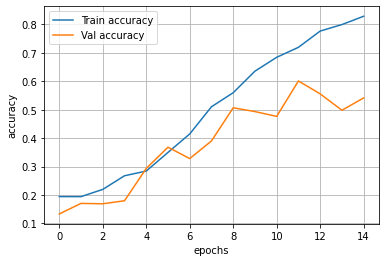

In [ ]:
# Train and Validation Loss Graph
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.grid()
plt.show()

# Train and Validation Accuracy Graph
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.grid()
plt.show()

In [ ]:
y_pred = model.predict(x_test)                    # Predicted values from the test data
y_pred = (y_pred >0.5)                            # Taking the highest probability value
y_pred1 = y_pred.argmax(axis=1)                  
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.64      0.70      2252
           1       0.12      0.05      0.08       219
           2       0.15      0.08      0.10       418
           3       0.07      0.02      0.03        56
           4       0.09      0.02      0.03        55

   micro avg       0.67      0.49      0.57      3000
   macro avg       0.24      0.16      0.19      3000
weighted avg       0.61      0.49      0.54      3000
 samples avg       0.49      0.49      0.49      3000



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
confusion_matrix(y_test1,y_pred1)

array([[1990,   69,  174,   11,    8],
       [ 193,   12,   14,    0,    0],
       [ 365,   15,   34,    2,    2],
       [  51,    1,    3,    1,    0],
       [  49,    0,    5,    0,    1]])